# Exploratory Data Analysis (EDA) — Heart Disease Dataset

This notebook performs exploratory data analysis on the **Heart Disease dataset** (`heart.csv`).

The dataset contains **1025 patient records** across **14 columns** — clinical measurements (age, blood pressure, cholesterol, etc.) and a binary **target** variable indicating the presence (`1`) or absence (`0`) of heart disease.

**Column reference:**

| Column | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| restecg | Resting ECG results (0-2) |
| thalach | Max heart rate achieved |
| exang | Exercise-induced angina (1 = yes, 0 = no) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of the peak exercise ST segment (0-2) |
| ca | Number of major vessels colored by fluoroscopy (0-4) |
| thal | Thalassemia (0-3) |
| target | 1 = heart disease present, 0 = absent |

**Workflow:**
1. Load and inspect the data
2. Check data types, missing values and duplicates
3. Separate numerical vs categorical features
4. Univariate analysis (distributions)
5. Bivariate analysis (features vs target)
6. Correlation analysis
7. Outlier detection (boxplots)
8. Export a consolidated EDA report (PDF)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

pd.set_option("display.max_columns", None)


## 1. Load the Dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Shape of dataset:", df.shape)


Shape of dataset: (1025, 14)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## 2. Data Quality Checks — Missing Values & Duplicates

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


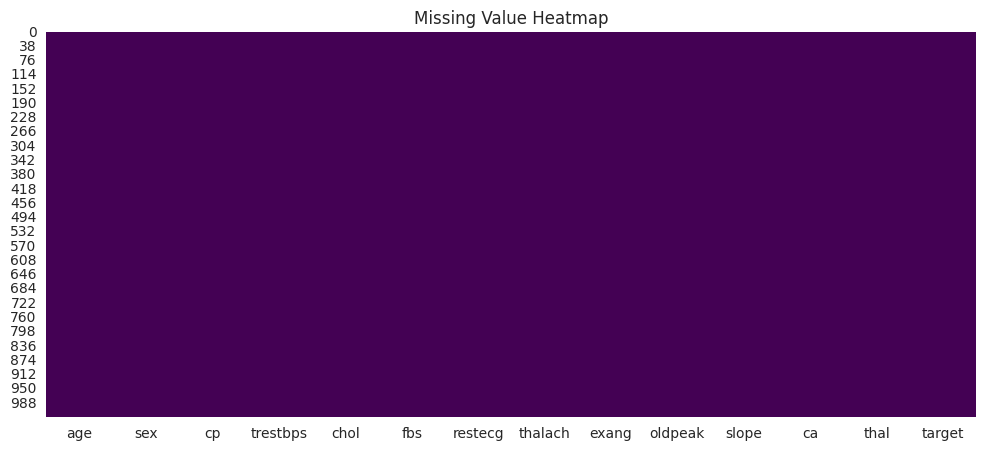

In [7]:
fig1 = plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


**Observation:** The missing value heatmap shows a uniform color across all features, confirming that the dataset has **no missing values** — no imputation is required.

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 723


**Observation:** The dataset contains duplicate rows (a known characteristic of this popular heart-disease CSV, which stacks repeated samples from the original UCI data). These are kept here for EDA purposes, but should be dropped before model training if the goal is predictive modeling.

## 3. Numerical vs Categorical Features

Although every column in this dataset is stored numerically, several of them are actually **categorical / discrete-coded** clinical flags (e.g. `sex`, `cp`, `fbs`). We split the columns by *meaning* rather than by pandas dtype so the rest of the analysis treats each feature appropriately.

In [9]:
# True continuous (numerical) features
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Categorical / discrete-coded features (including the target)
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


## 4. Target Variable Distribution

In [10]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3) * 100, "%")


target
1    526
0    499
Name: count, dtype: int64

target
1    51.3
0    48.7
Name: proportion, dtype: float64 %


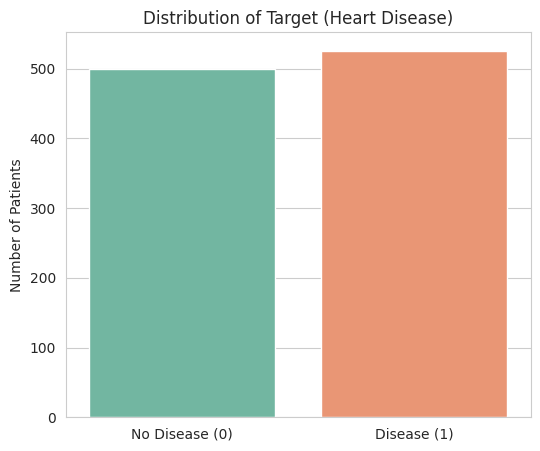

In [11]:
fig2 = plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
plt.title("Distribution of Target (Heart Disease)")
plt.ylabel("Number of Patients")
plt.xlabel("")
plt.show()


**Observation:** The target classes are fairly **balanced** (about 51% positive vs 49% negative), so accuracy-based metrics should be reasonably reliable for any downstream classification model.

## 5. Univariate Analysis — Numerical Feature Distributions

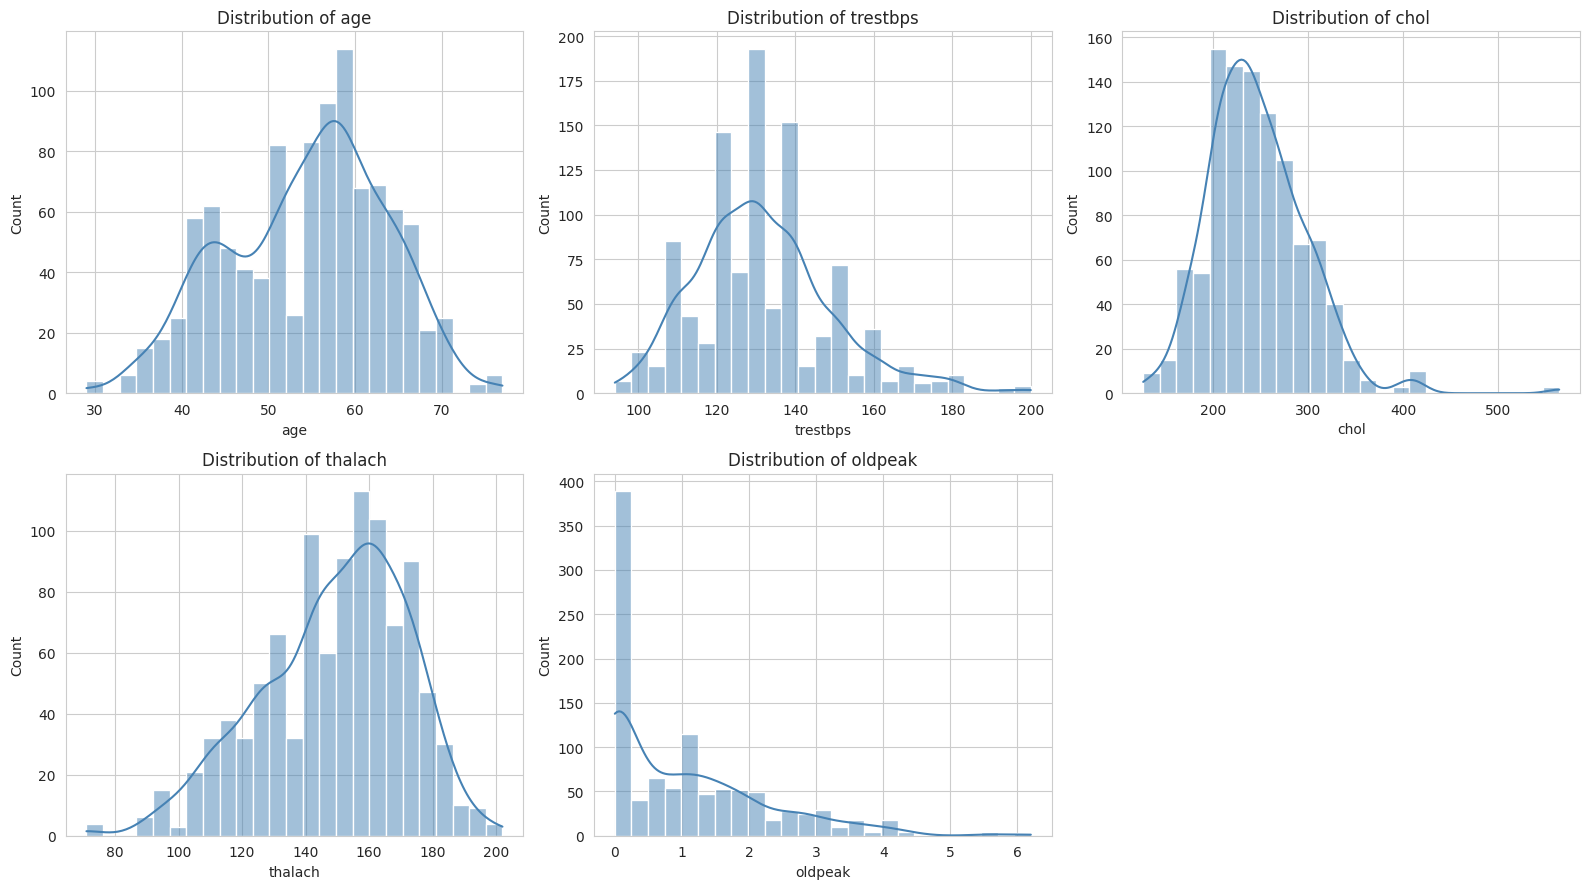

In [12]:
fig3, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], bins=25, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

# hide the unused 6th subplot
for j in range(len(numerical_features), len(axes)):
    fig3.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Observations:**
- **age**: roughly bell-shaped, most patients are between 45 and 65 years old.
- **trestbps** (resting blood pressure): right-skewed with a peak around 120-140 mm Hg; some high outliers above 170.
- **chol** (cholesterol): right-skewed, most values fall between 200-300 mg/dl, with a long tail of high values.
- **thalach** (max heart rate): roughly normal, centered around 150-160 bpm, slightly left-skewed.
- **oldpeak** (ST depression): heavily right-skewed with a large spike at 0, indicating many patients show no ST depression.

## 6. Univariate Analysis — Categorical Feature Counts

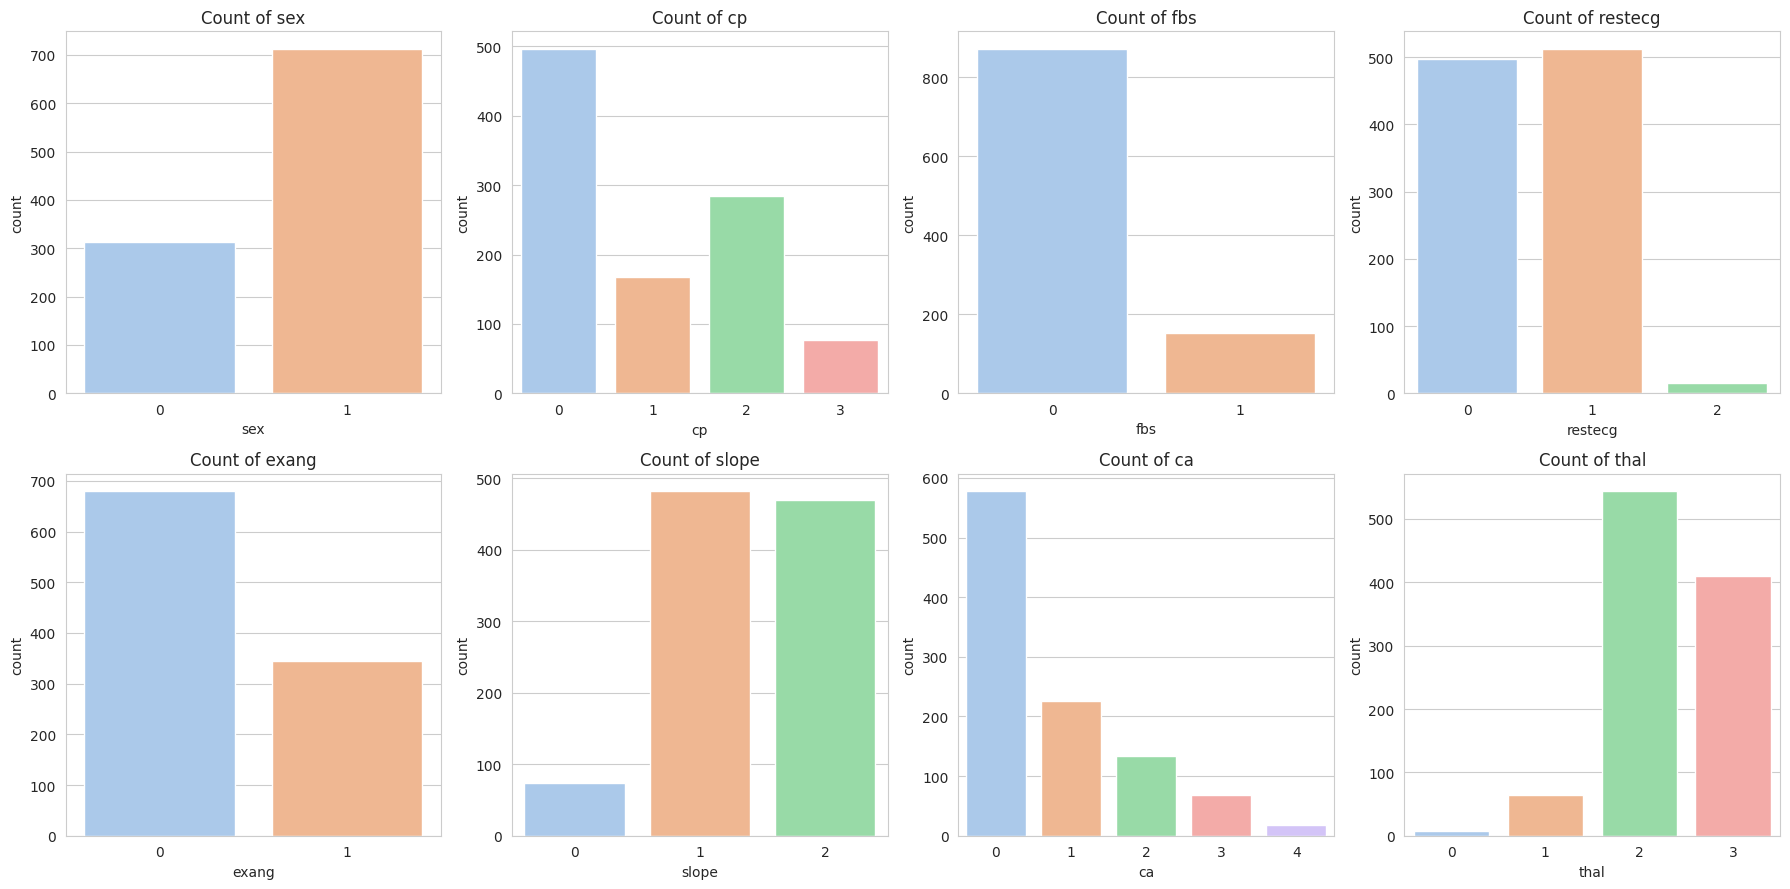

In [13]:
cat_only = [c for c in categorical_features if c != "target"]

fig4, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_only):
    sns.countplot(data=df, x=col, hue=col, palette="pastel", legend=False, ax=axes[i])
    axes[i].set_title(f"Count of {col}")

plt.tight_layout()
plt.show()


## 7. Bivariate Analysis — Numerical Features vs Target

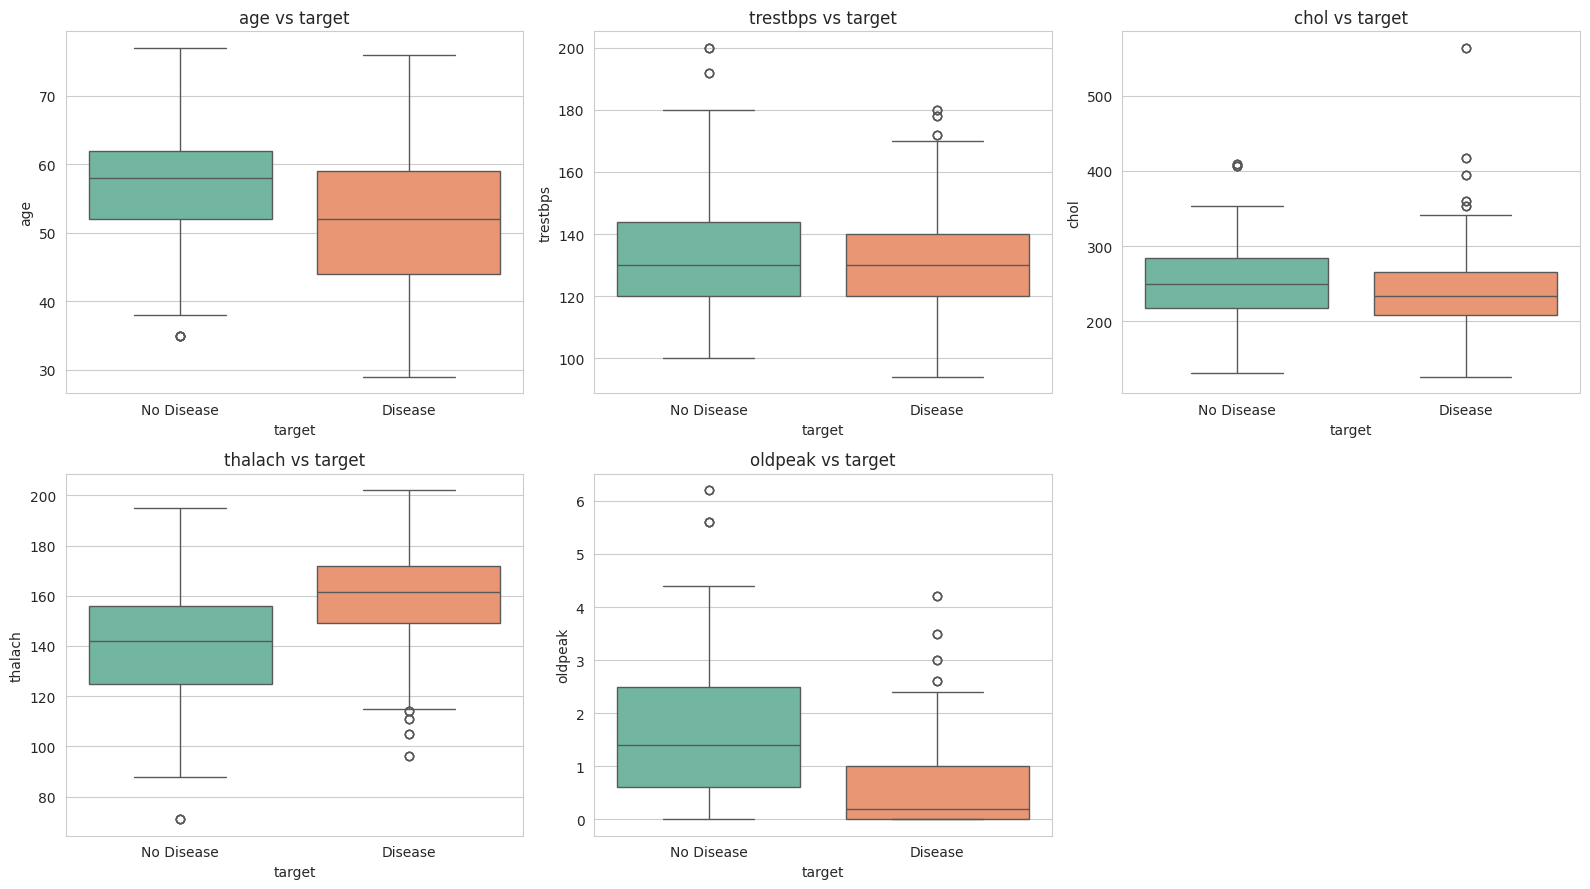

In [14]:
fig5, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x="target", y=col, data=df, hue="target", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Disease", "Disease"])
    axes[i].set_title(f"{col} vs target")

for j in range(len(numerical_features), len(axes)):
    fig5.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Observations:**
- **thalach** (max heart rate) is noticeably **higher** in patients with heart disease — a strong separating feature.
- **oldpeak** is **lower** for patients with heart disease, and higher (with more high outliers) for those without.
- **age** is slightly lower on average for the disease-positive group in this dataset, somewhat counter-intuitive but consistent with this specific CSV.
- **trestbps** and **chol** show only mild differences between the two target classes.

## 8. Bivariate Analysis — Categorical Features vs Target

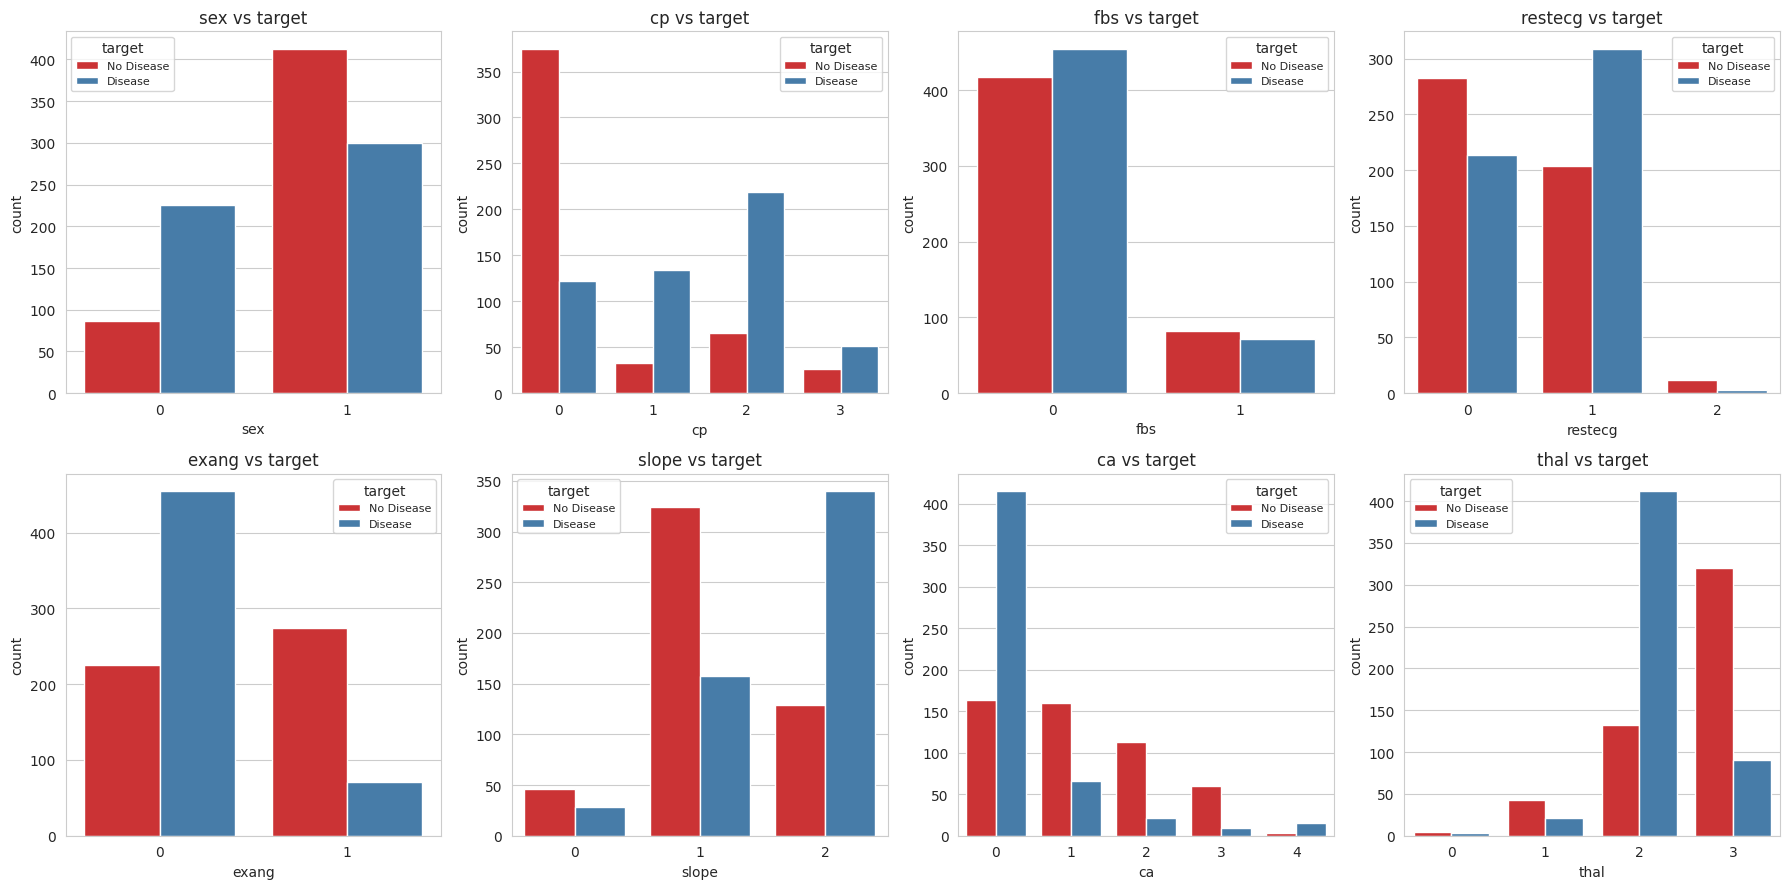

In [15]:
fig6, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_only):
    sns.countplot(data=df, x=col, hue="target", palette="Set1", ax=axes[i])
    axes[i].set_title(f"{col} vs target")
    axes[i].legend(title="target", labels=["No Disease", "Disease"], fontsize=8)

plt.tight_layout()
plt.show()


**Observations:**
- **cp** (chest pain type): patients with chest pain types 1-3 (atypical/non-anginal/asymptomatic-coded) show much higher rates of disease than type 0.
- **exang** (exercise-induced angina): patients **without** exercise-induced angina (0) are disproportionately in the disease-positive group.
- **thal**: thal = 2 is strongly associated with disease presence, while thal = 3 leans toward no disease.
- **ca** (number of major vessels colored): ca = 0 is strongly associated with disease presence; disease likelihood drops as ca increases.
- **sex**: the dataset contains more males than females; disease prevalence differs somewhat by sex but is less extreme than cp, thal, or ca.

## 9. Correlation Analysis

In [16]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix.round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.10,-0.07,0.27,0.22,0.12,-0.13,-0.39,0.09,0.21,-0.17,0.27,0.07,-0.23
sex,-0.10,1.00,-0.04,-0.08,-0.20,0.03,-0.06,-0.05,0.14,0.08,-0.03,0.11,0.20,-0.28
cp,-0.07,-0.04,1.00,0.04,-0.08,0.08,0.04,0.31,-0.40,-0.17,0.13,-0.18,-0.16,0.43
trestbps,0.27,-0.08,0.04,1.00,0.13,0.18,-0.12,-0.04,0.06,0.19,-0.12,0.10,0.06,-0.14
chol,0.22,-0.20,-0.08,0.13,1.00,0.03,-0.15,-0.02,0.07,0.06,-0.01,0.07,0.10,-0.10
fbs,0.12,0.03,0.08,0.18,0.03,1.00,-0.10,-0.01,0.05,0.01,-0.06,0.14,-0.04,-0.04
restecg,-0.13,-0.06,0.04,-0.12,-0.15,-0.10,1.00,0.05,-0.07,-0.05,0.09,-0.08,-0.02,0.13
thalach,-0.39,-0.05,0.31,-0.04,-0.02,-0.01,0.05,1.00,-0.38,-0.35,0.40,-0.21,-0.10,0.42
exang,0.09,0.14,-0.40,0.06,0.07,0.05,-0.07,-0.38,1.00,0.31,-0.27,0.11,0.20,-0.44
oldpeak,0.21,0.08,-0.17,0.19,0.06,0.01,-0.05,-0.35,0.31,1.00,-0.58,0.22,0.20,-0.44


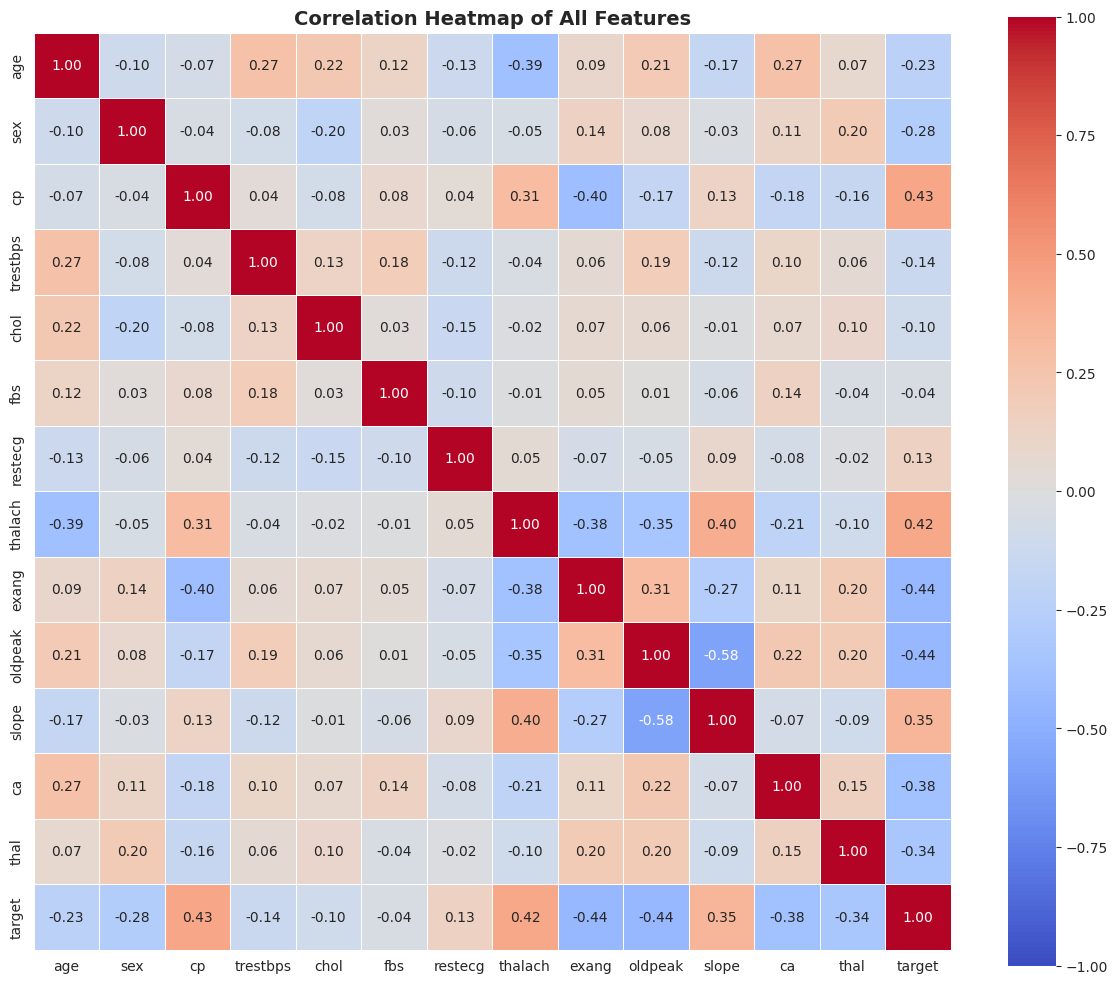

In [17]:
fig7 = plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of All Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [18]:
target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)
target_corr


oldpeak    -0.438441
exang      -0.438029
cp          0.434854
thalach     0.422895
ca         -0.382085
slope       0.345512
thal       -0.337838
sex        -0.279501
age        -0.229324
trestbps   -0.138772
restecg     0.134468
chol       -0.099966
fbs        -0.041164
Name: target, dtype: float64

**Observations:**
- **cp**, **thalach**, and **slope** have the strongest **positive** correlation with `target`.
- **exang**, **oldpeak**, **ca**, and **thal** have the strongest **negative** correlation with `target`.
- No pair of independent features shows extreme multicollinearity (|r| > 0.8), so all features can reasonably be kept for modeling.
- `thalach` and `age` are moderately negatively correlated (max heart rate tends to fall with age), matching physiological expectations.

## 10. Outlier Detection — Boxplots of Numerical Features

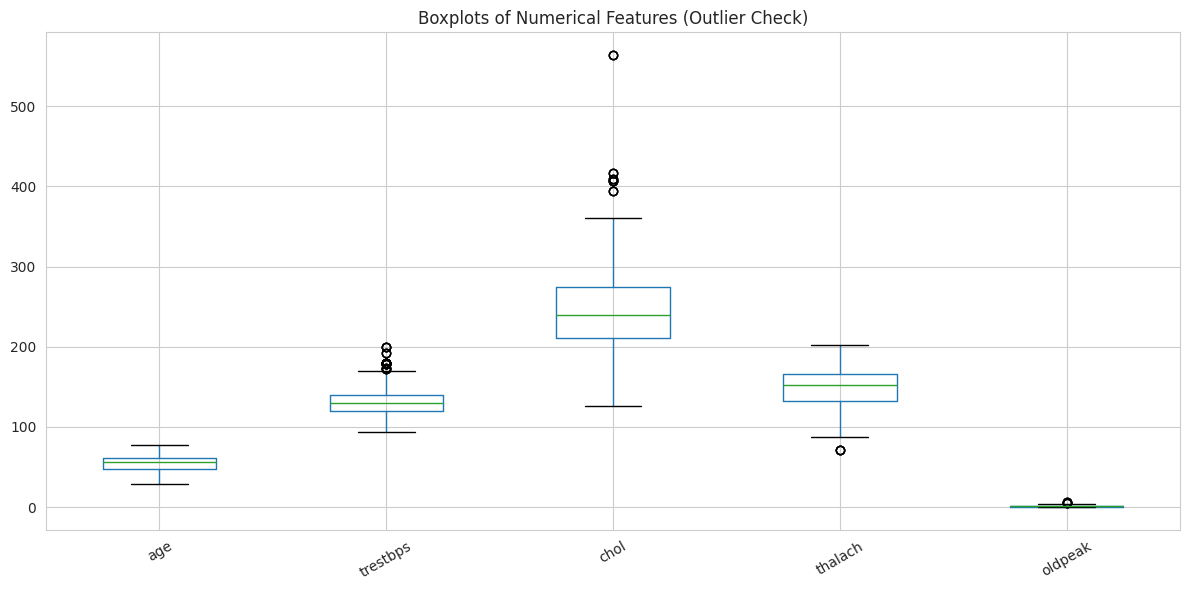

In [19]:
fig8 = plt.figure(figsize=(12, 6))
df[numerical_features].boxplot()
plt.xticks(rotation=30)
plt.title("Boxplots of Numerical Features (Outlier Check)")
plt.tight_layout()
plt.show()


In [20]:
# Quantify outliers using the IQR method
print("Outlier counts (IQR method):\n")
for col in numerical_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col:10s}: {n_outliers} outliers  (valid range: {lower:.1f} to {upper:.1f})")


Outlier counts (IQR method):

age       : 0 outliers  (valid range: 28.5 to 80.5)
trestbps  : 30 outliers  (valid range: 90.0 to 170.0)
chol      : 16 outliers  (valid range: 115.0 to 371.0)
thalach   : 4 outliers  (valid range: 81.0 to 217.0)
oldpeak   : 7 outliers  (valid range: -2.7 to 4.5)


**Observation:** `chol` (cholesterol) and `trestbps` (resting blood pressure) show the most outliers on the high end, which is clinically plausible (some patients have genuinely elevated readings) rather than data-entry errors. `oldpeak` and `ca` also show a handful of outliers driven by their skewed / discrete distributions.

## 11. Export Consolidated EDA Report (PDF)

In [21]:
from matplotlib.backends.backend_pdf import PdfPages

output_dir = "."
report_path = os.path.join(output_dir, "Heart_EDA_Report.pdf")

figures = [fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8]

with PdfPages(report_path) as pdf:
    for fig in figures:
        pdf.savefig(fig)

print(f"EDA report saved successfully to: {report_path}")


EDA report saved successfully to: ./Heart_EDA_Report.pdf


## 12. Summary of Key Findings

- The dataset has **1025 rows, 14 columns**, no missing values, and a fairly **balanced target** (~51% disease / 49% no disease).
- Five features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) are genuinely continuous; the remaining columns are categorical/discrete clinical codes.
- The strongest predictors of heart disease appear to be **cp** (chest pain type), **thalach** (max heart rate), **exang** (exercise-induced angina), **oldpeak**, **ca**, and **thal**.
- `chol` and `trestbps` contain some high-end outliers that are clinically plausible and likely worth keeping (or capping) rather than removing outright.
- No pair of features is severely multicollinear, so no feature needs to be dropped purely on correlation grounds before modeling.
- Next steps: drop duplicate rows if building a predictive model, consider scaling continuous features, and one-hot encode multi-level categorical columns (`cp`, `restecg`, `slope`, `ca`, `thal`) if using a linear/distance-based model.